## TRABAJO FINAL - APROBACIÓN DE CRÉDITOS BANCARIOS Y  EVALUACIÓN DE RIESGO ##

Importamos librerias y consolidamos dataset.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore' , category=FutureWarning)   

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE



app_df = pd.read_csv('application_record.csv')
credit_df = pd.read_csv('credit_record.csv')
credit_df['Is_Bad'] = credit_df['STATUS'].isin(['2', '3', '4', '5']).astype(int)
target_df = credit_df.groupby('ID')['Is_Bad'].max().reset_index()
target_df.rename(columns={'Is_Bad': 'Target'}, inplace=True)
df = pd.merge(app_df, target_df, on='ID', how='inner')
df = df.drop(columns=['ID'])
print(f"Dimensiones del dataset consolidado: {df.shape}")
print("\nDistribución de la Variable Objetivo (Target):")
print(df['Target'].value_counts(normalize=True) * 100)

Dimensiones del dataset consolidado: (36457, 18)

Distribución de la Variable Objetivo (Target):
Target
0    98.310338
1     1.689662
Name: proportion, dtype: float64


In [ ]:
Limpieza de Datos.

In [ ]:

df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Other_Unknown')
df['Age_Years'] = np.abs(df['DAYS_BIRTH']) // 365
df = df.drop(columns=['DAYS_BIRTH'])
df['Years_Employed'] = np.abs(df['DAYS_EMPLOYED']) // 365
df['Years_Employed'] = df['Years_Employed'].apply(lambda x: 0 if x > 500 else x)  # Ajuste de banderas arbitrarias
df = df.drop(columns=['DAYS_EMPLOYED'])

print("Limpieza inicial completada. Primeros registros:")
df.head()

Limpieza inicial completada. Primeros registros:


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Target,Age_Years,Years_Employed
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Other_Unknown,2.0,0,32,12
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Other_Unknown,2.0,0,32,12
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58,3
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8


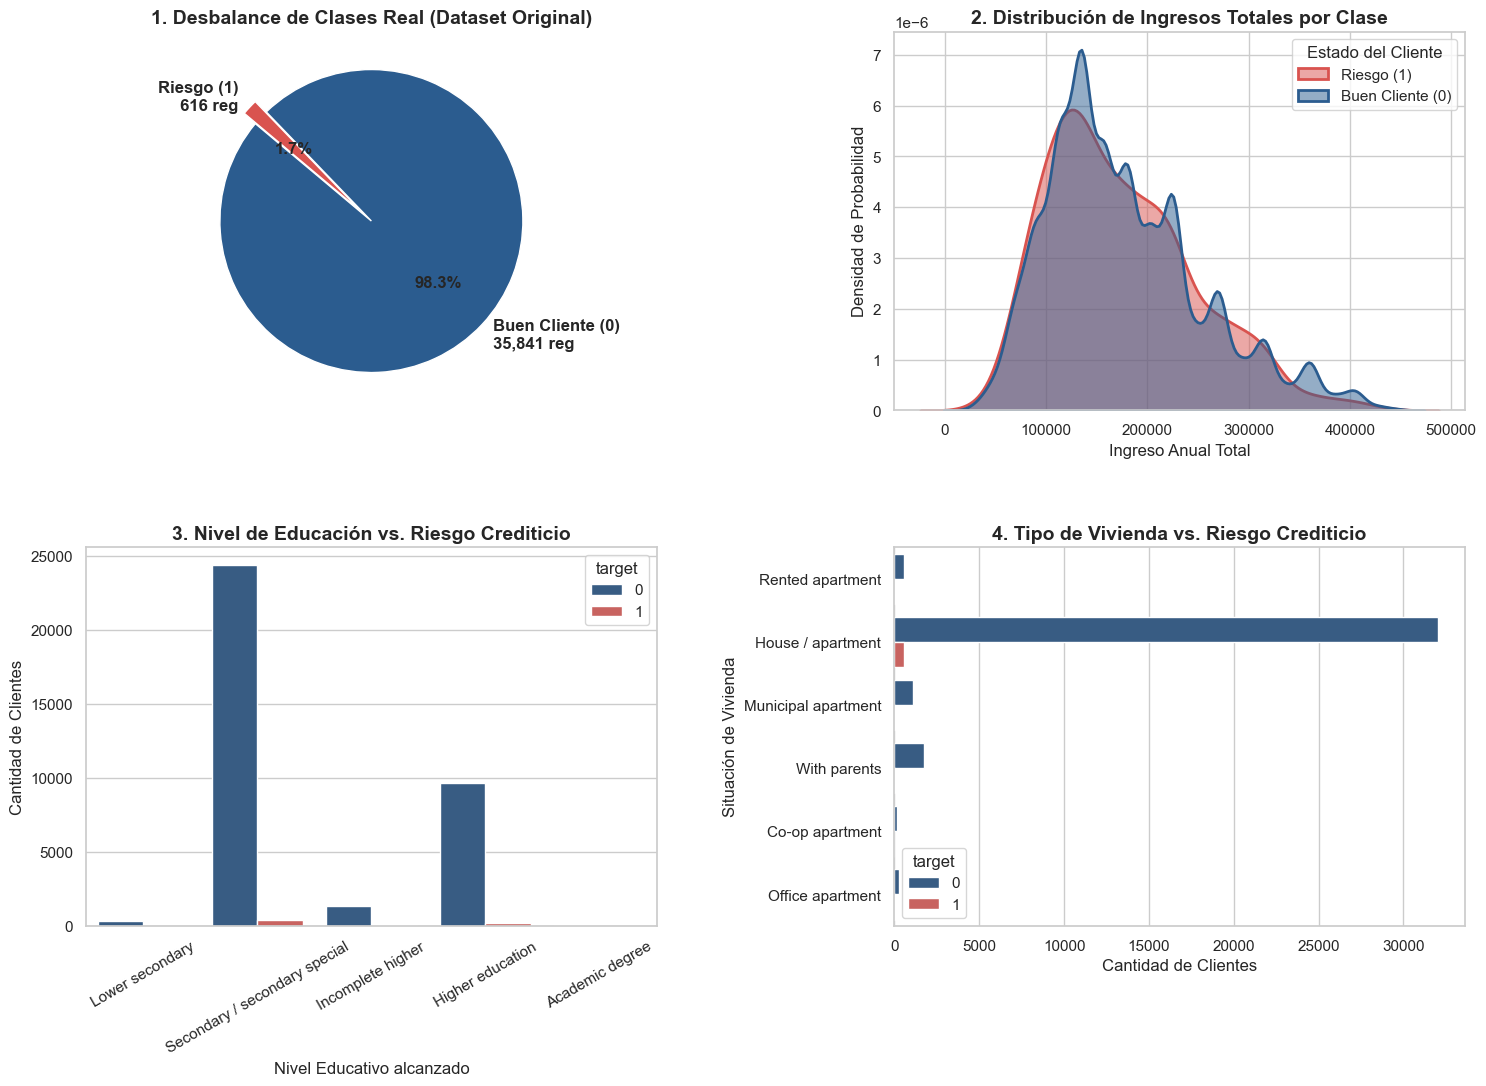

In [ ]:



sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------------

class_counts = df['target'].value_counts()
labels = [f'Buen Cliente (0)\n{class_counts[0]:,} reg', f'Riesgo (1)\n{class_counts[1]:,} reg']
colors = ['#2b5c8f', '#d9534f'] # Azul corporativo / Rojo alerta

axes[0, 0].pie(
    class_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=(0, 0.1), # Resaltar la clase minoritaria
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0, 0].set_title('1. Desbalance de Clases Real (Dataset Original)', fontsize=14, fontweight='bold')


# ------------------------------------------------------------------
# Filtramos ingresos extremos para una mejor visualización (opcional)
q_limit = df['AMT_INCOME_TOTAL'].quantile(0.98)
income_df = df[df['AMT_INCOME_TOTAL'] < q_limit]

sns.kdeplot(
    data=income_df, 
    x='AMT_INCOME_TOTAL', 
    hue='target', 
    fill=True, 
    common_norm=False, 
    palette=colors, 
    alpha=0.5, 
    linewidth=2,
    ax=axes[0, 1]
)
axes[0, 1].set_title('2. Distribución de Ingresos Totales por Clase', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Ingreso Anual Total', fontsize=12)
axes[0, 1].set_ylabel('Densidad de Probabilidad', fontsize=12)
axes[0, 1].legend(title='Estado del Cliente', labels=['Riesgo (1)', 'Buen Cliente (0)']) # Invertir leyenda por hue


# ------------------------------------------------------------------
education_order = [
    'Lower secondary', 'Secondary / secondary special', 
    'Incomplete higher', 'Higher education', 'Academic degree'
]

sns.countplot(
    data=df, 
    x='NAME_EDUCATION_TYPE', 
    hue='target', 
    order=education_order,
    palette=colors,
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. Nivel de Educación vs. Riesgo Crediticio', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Nivel Educativo alcanzado', fontsize=12)
axes[1, 0].set_ylabel('Cantidad de Clientes', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=30) # Rotar etiquetas para legibilidad

# ------------------------------------------------------------------

sns.countplot(
    data=df, 
    y='NAME_HOUSING_TYPE', 
    hue='target', 
    palette=colors,
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Tipo de Vivienda vs. Riesgo Crediticio', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Cantidad de Clientes', fontsize=12)
axes[1, 1].set_ylabel('Situación de Vivienda', fontsize=12)

# Ajuste final de diseño
plt.tight_layout(pad=4.0)
plt.show()

Definición del Pipeline de Preprocesamiento y Train/Test Split

In [ ]:

X = df.drop(columns=['Target'])
y = df['Target']
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Forma de X_train procesado: {X_train_prep.shape}")

Forma de X_train procesado: (29165, 55)


Manejo de desvalanceo con SMOTE

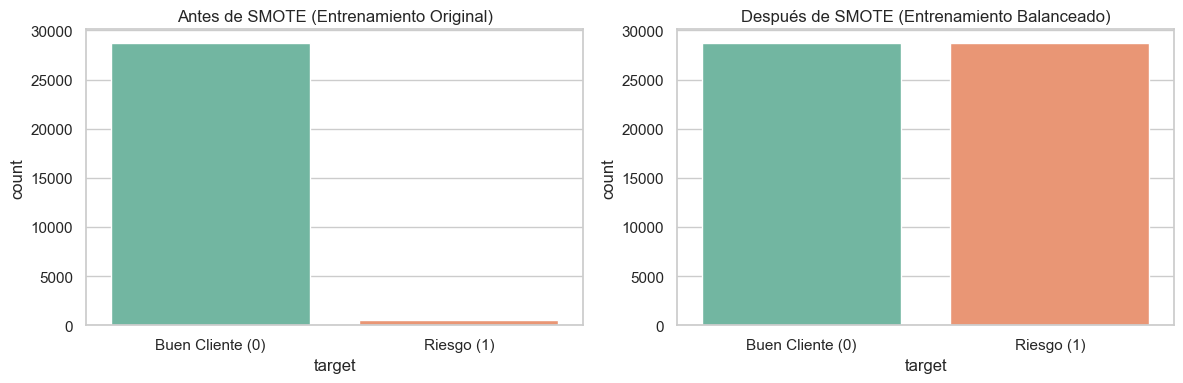

Frecuencia original de clases en Train:
 target
0    28672
1      493
Name: count, dtype: int64

Frecuencia balanceada de clases con SMOTE:
 target
0    28672
1    28672
Name: count, dtype: int64


In [28]:
# Inicializamos SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_prep, y_train)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0], palette='Set2')
axes[0].set_title('Antes de SMOTE (Entrenamiento Original)')
axes[0].set_xticklabels(['Buen Cliente (0)', 'Riesgo (1)'])

sns.countplot(x=y_train_resampled, ax=axes[1], palette='Set2')
axes[1].set_title('Después de SMOTE (Entrenamiento Balanceado)')
axes[1].set_xticklabels(['Buen Cliente (0)', 'Riesgo (1)'])

plt.tight_layout()
plt.show()

print("Frecuencia original de clases en Train:\n", y_train.value_counts())
print("\nFrecuencia balanceada de clases con SMOTE:\n", pd.Series(y_train_resampled).value_counts())

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)    

In [9]:

import sys
!{sys.executable} -m pip install xgboost imbalanced-learn

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)


In [ ]:
Entrenamiento de Modelos y Medición de Métricas 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Support Vector Classifier': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

# Diccionario para almacenar métricas
model_results = {}

print("=== INICIANDO ENTRENAMIENTO DE MODELOS ===")

for name, model in models.items():
    print(f"\nEntrenando {name}...")
    
    # Entrenamiento con datos de SMOTE
    model.fit(X_train_resampled, y_train_resampled)
    
    # Evaluamos en el set de prueba real NO balanceado
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    model_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'model_object': model,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

df_metrics = pd.DataFrame(model_results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
print("\n=== TABLA COMPARATIVA DE MÉTRICAS ===")
df_metrics

=== INICIANDO ENTRENAMIENTO DE MODELOS ===

Entrenando Random Forest...

Entrenando Support Vector Classifier...

Entrenando XGBoost...

=== TABLA COMPARATIVA DE MÉTRICAS ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.979018,0.325581,0.227642,0.267943,0.81438
Support Vector Classifier,0.918267,0.078431,0.357724,0.128655,0.673549
XGBoost,0.97751,0.269663,0.195122,0.226415,0.656616


Visualización Comparativa de Métricas

<Figure size 1200x600 with 0 Axes>

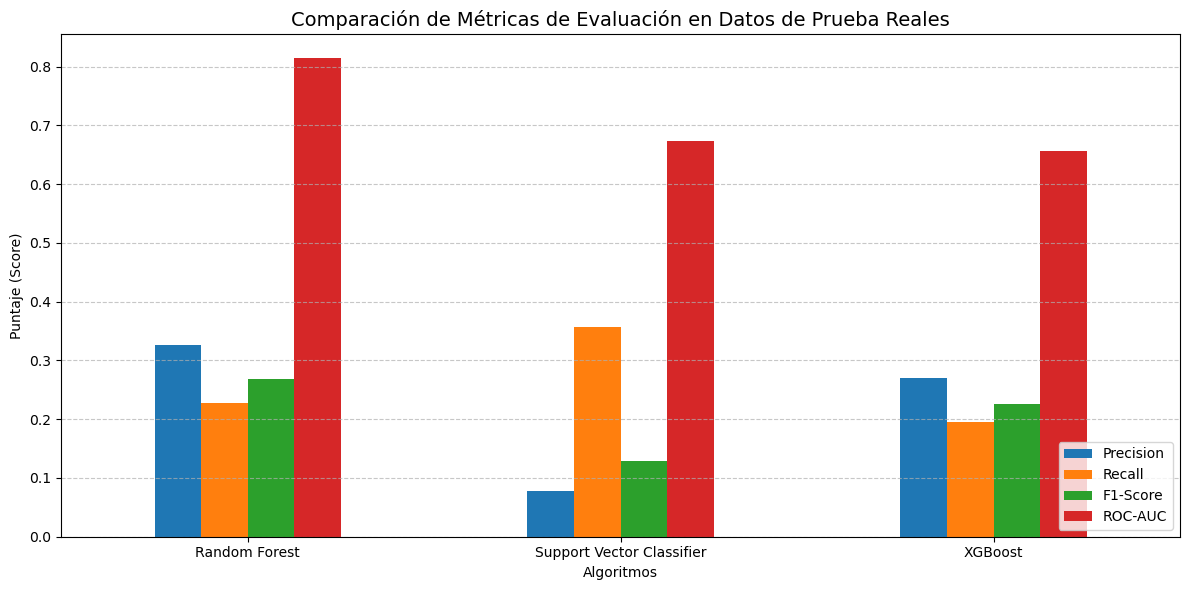

In [12]:
# Gráfica de barras comparativa
plt.figure(figsize=(12, 6))
df_metrics[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Métricas de Evaluación en Datos de Prueba Reales', fontsize=14)
plt.ylabel('Puntaje (Score)')
plt.xlabel('Algoritmos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Extracción y Gráfica de Feature Importantes

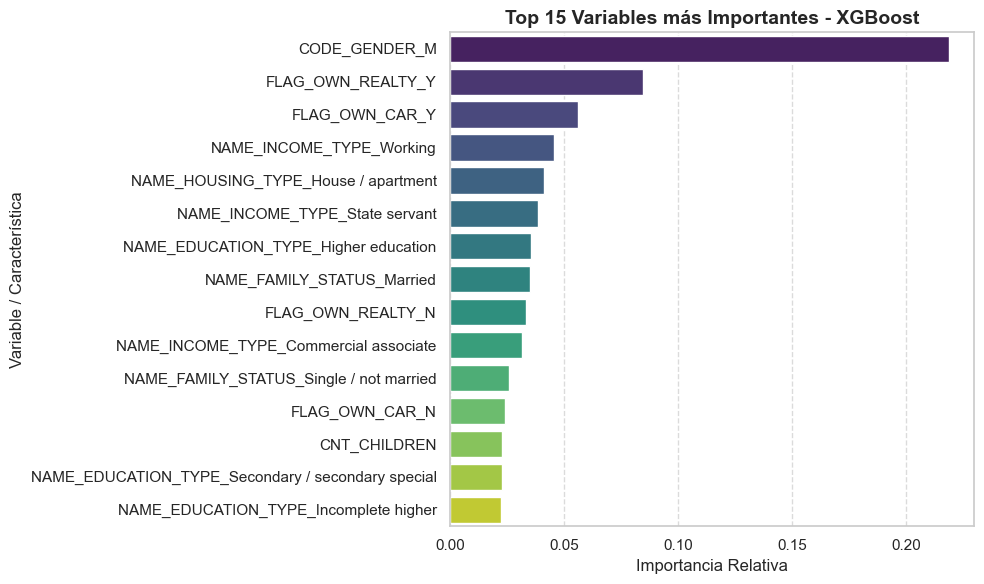

Top 10 variables con mayor peso en el modelo:


,Feature,Importance
0,CODE_GENDER_M,0.218885
1,FLAG_OWN_REALTY_Y,0.084752
2,FLAG_OWN_CAR_Y,0.056182
3,NAME_INCOME_TYPE_Working,0.045486
4,NAME_HOUSING_TYPE_House / apartment,0.041169
5,NAME_INCOME_TYPE_State servant,0.038555
6,NAME_EDUCATION_TYPE_Higher education,0.035718
7,NAME_FAMILY_STATUS_Married,0.035148
8,FLAG_OWN_REALTY_N,0.033342
9,NAME_INCOME_TYPE_Commercial associate,0.031540


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


selected_model_name = 'XGBoost'  # O 'Random Forest'
model_obj = model_results[selected_model_name]['model_object']

encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(encoded_cat_cols)

importances = model_obj.feature_importances_

df_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_n = 15
df_top = df_importance.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_top, 
    palette='viridis'
)

plt.title(f'Top {top_n} Variables más Importantes - {selected_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable / Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 variables con mayor peso en el modelo:")
display(df_top.head(10).reset_index(drop=True))

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)   

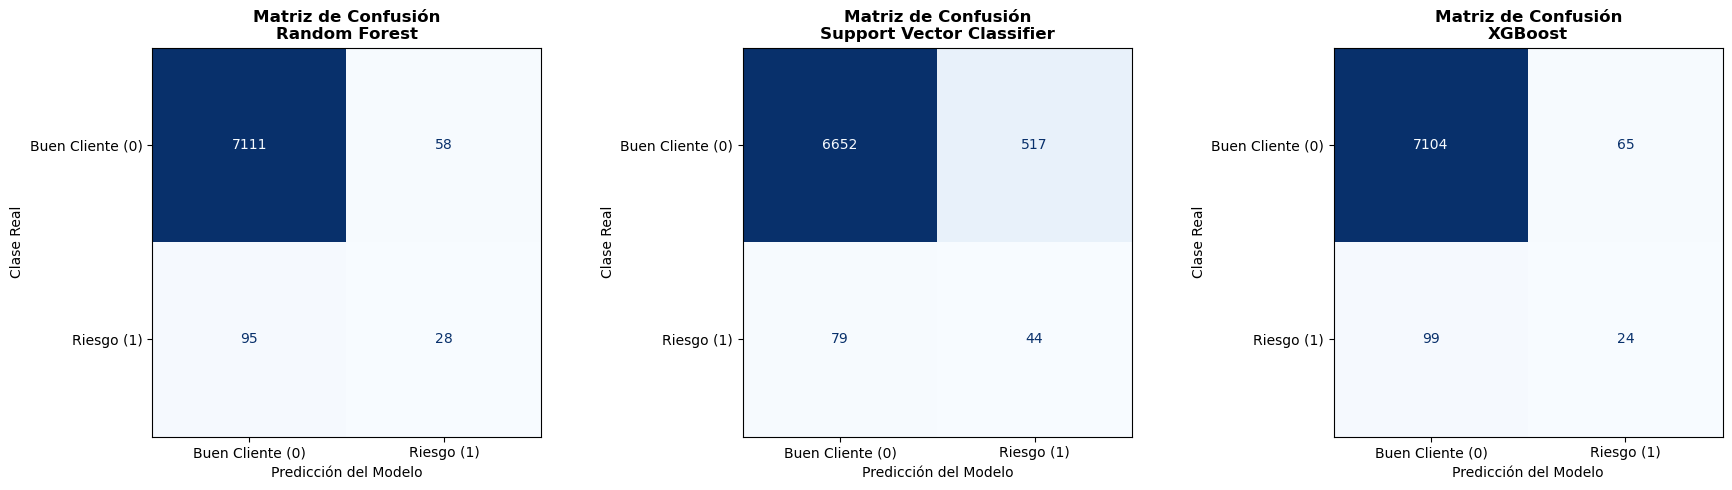

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, model_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Buen Cliente (0)', 'Riesgo (1)']
    )
                        
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    
    ax.set_title(f'Matriz de Confusión\n{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo')
    ax.set_ylabel('Clase Real')

plt.tight_layout()
plt.show()